# Part 3 — Final Results

This notebook presents the principal results from the fully executed `03_modeling.ipynb` workflow in a concise form. Notebook 03 generates `data/processed/final_results.json`; this notebook reads that synchronized bundle instead of copying numerical results by hand.

**Primary metric:** mean absolute error (MAE) in euros per night.  
**Secondary metrics:** RMSE, R², and the proportions of predictions within €25 and €50.

The project evaluates tabular, spatial, and text-derived modalities. The training-selected final model retains tabular and spatial predictors because the six simple text-quantity features did not improve Random Forest validation performance.

Missing numeric values are reconstructed from their original missingness indicators and imputed inside each training split. The primary evaluation is a fixed listing-level holdout, supplemented by repeated random splits, an unseen-host stress test, calibration diagnostics, and bootstrap uncertainty estimates.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def locate_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "processed" / "final_results.json").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate data/processed/final_results.json. "
        "Run notebooks/03_modeling.ipynb completely before Notebook 04."
    )


PROJECT_ROOT = locate_project_root()
RESULTS_PATH = PROJECT_ROOT / "data" / "processed" / "final_results.json"
with RESULTS_PATH.open("r", encoding="utf-8") as handle:
    results = json.load(handle)

metadata = results["metadata"]

def result_table(name: str) -> pd.DataFrame:
    return pd.DataFrame(results["tables"][name])

print("Loaded synchronized results from:", RESULTS_PATH)
print("Selected model:", metadata["selected_model"])

Loaded synchronized results from: C:\Personal Documents\Masters\Semester 2\Machine_Learning\airbnb-price-prediction-berlin\data\processed\final_results.json
Selected model: Random Forest — log target, no text


## 1. Main holdout comparison

The final candidate was selected using training-only cross-validation. The fixed test set was evaluated only after model, target-scale, and text-feature choices were fixed.

,model,train_mae,test_mae,test_rmse,test_r2,test_median_absolute_error,test_within_25_eur,test_within_50_eur
0,"Random Forest — log target, no text",13.556,29.586,49.244,0.645,17.490,0.632,0.844
1,"PyTorch MLP — log target, no text",24.231,30.104,48.782,0.651,18.305,0.620,0.834
2,"Random Forest — raw target, full features",13.396,30.855,48.323,0.658,20.292,0.582,0.837
3,"Gradient Boosting — selected loss, full features",30.363,32.134,50.872,0.621,21.354,0.569,0.822
4,Linear Regression,38.053,38.229,55.526,0.548,28.068,0.451,0.753
5,"Ridge — raw target, full features",38.070,38.266,55.557,0.548,28.042,0.451,0.753
6,Median baseline,56.843,57.450,85.866,-0.080,40.000,0.325,0.619
7,Mean baseline,59.659,60.316,82.621,-0.000,49.288,0.241,0.506


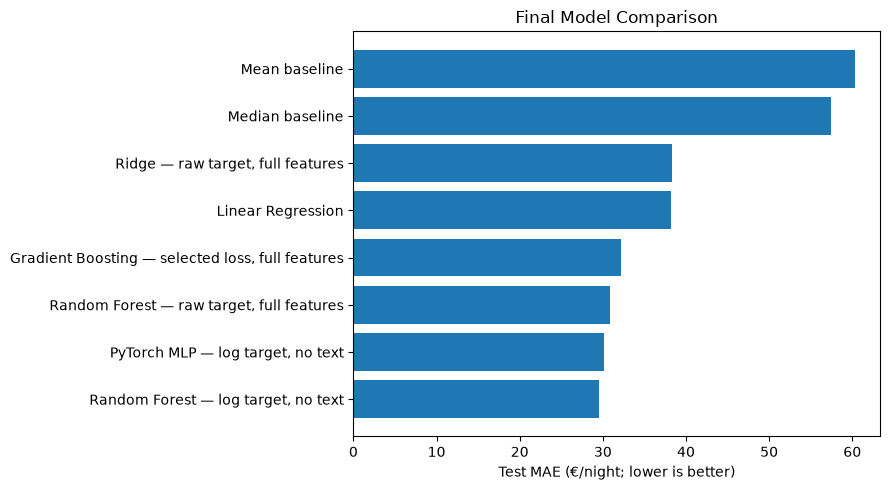

### Final selected model

The selected model is **Random Forest — log target, no text**. It achieved a fixed-test MAE of **€29.59**, RMSE of **€49.24**, and R² of **0.645**. **63.2%** of predictions were within €25 and **84.4%** were within €50.


In [2]:
model_comparison = result_table("model_comparison").sort_values("test_mae").reset_index(drop=True)
columns = [
    "model", "train_mae", "test_mae", "test_rmse", "test_r2",
    "test_median_absolute_error", "test_within_25_eur", "test_within_50_eur",
]
display(model_comparison[columns])

fig, ax = plt.subplots(figsize=(9, 5))
plot_data = model_comparison.sort_values("test_mae", ascending=True)
ax.barh(plot_data["model"], plot_data["test_mae"])
ax.set_xlabel("Test MAE (€/night; lower is better)")
ax.set_title("Final Model Comparison")
fig.tight_layout()
plt.show()

selected = model_comparison.loc[
    model_comparison["model"].eq(metadata["selected_model"])
].iloc[0]
display(Markdown(f"""### Final selected model

The selected model is **{metadata['selected_model']}**. It achieved a fixed-test MAE of **€{selected['test_mae']:.2f}**, RMSE of **€{selected['test_rmse']:.2f}**, and R² of **{selected['test_r2']:.3f}**. **{selected['test_within_25_eur']:.1%}** of predictions were within €25 and **{selected['test_within_50_eur']:.1%}** were within €50.
"""))

## 2. Training cross-validation and PyTorch MLP decision

In [3]:
candidate_cv = result_table("candidate_cv").sort_values("mean_cv_mae").reset_index(drop=True)
display(candidate_cv[[
    "candidate", "target_scale", "text_setting", "mean_cv_mae", "sd_cv_mae",
    "mean_cv_rmse", "mean_cv_r2"
]])

mlp_row = candidate_cv.loc[candidate_cv["candidate"].str.startswith("PyTorch MLP")].iloc[0]
best_row = candidate_cv.iloc[0]
mae_gap = mlp_row["mean_cv_mae"] - best_row["mean_cv_mae"]
display(Markdown(
    f"The selected MLP architecture was **{metadata['selected_mlp_architecture']}**. "
    f"Its training cross-validated MAE was **€{mlp_row['mean_cv_mae']:.2f}**, "
    f"which was **€{mae_gap:.2f}** higher than the training-selected candidate. "
    "The MLP is therefore retained as a controlled neural-network benchmark rather than the final model."
))

,candidate,target_scale,text_setting,mean_cv_mae,sd_cv_mae,mean_cv_rmse,mean_cv_r2
0,"Random Forest — log target, no text",log1p_price,without_text,30.297,0.552,49.677,0.623
1,"Random Forest — log target, full features",log1p_price,with_text,30.471,0.507,49.970,0.618
2,"PyTorch MLP — log target, no text",log1p_price,without_text,31.329,0.515,49.996,0.618
3,"Random Forest — raw target, no text",raw_price,without_text,31.570,0.520,49.004,0.633
4,"Random Forest — raw target, full features",raw_price,with_text,31.714,0.499,49.146,0.631
5,"Gradient Boosting — selected loss, full features",raw_price,with_text,32.273,0.353,50.716,0.607
6,"Ridge — log target, full features",log1p_price,with_text,37.043,0.249,58.786,0.472
7,"Ridge — raw target, full features",raw_price,with_text,38.597,0.489,56.258,0.516


The selected MLP architecture was **PyTorch MLP 128-64-32**. Its training cross-validated MAE was **€31.33**, which was **€1.03** higher than the training-selected candidate. The MLP is therefore retained as a controlled neural-network benchmark rather than the final model.

## 3. Stability across random train/test splits

These repeated splits are a sensitivity analysis for the fixed configurations, not nested validation of the complete selection procedure.

,model,mean_mae,sd_mae,mean_rmse,sd_rmse,mean_r2,mean_within_25,mean_within_50,sd_r2
0,"Random Forest — log target, no text",29.316,0.288,48.593,0.947,0.643,0.628,0.842,NaN
1,"PyTorch MLP — log target, no text",30.366,0.303,48.385,0.538,0.646,0.610,0.831,0.015
2,"Random Forest — raw target, full features",30.492,0.598,47.712,1.121,0.656,0.588,0.834,0.011
3,"Gradient Boosting — selected loss, full features",31.758,0.603,50.143,1.287,0.620,0.574,0.826,0.007
4,Linear Regression,38.169,0.589,55.124,1.081,0.541,0.447,0.751,0.013
5,"Ridge — raw target, full features",38.193,0.585,55.145,1.086,0.541,0.447,0.750,0.013


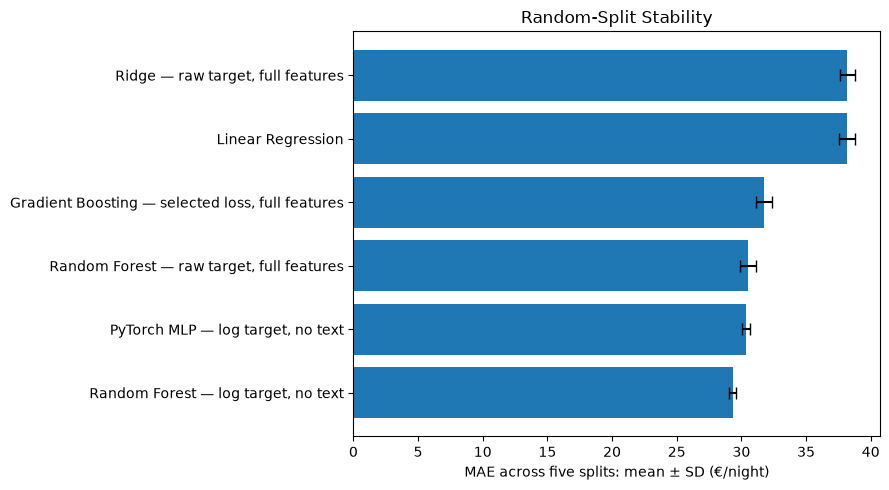

In [4]:
stability = result_table("stability").sort_values("mean_mae").reset_index(drop=True)
display(stability)

fig, ax = plt.subplots(figsize=(9, 5))
plot_data = stability.sort_values("mean_mae", ascending=True)
ax.barh(plot_data["model"], plot_data["mean_mae"], xerr=plot_data["sd_mae"], capsize=4)
ax.set_xlabel("MAE across five splits: mean ± SD (€/night)")
ax.set_title("Random-Split Stability")
fig.tight_layout()
plt.show()

## 4. Generalization to previously unseen hosts

The primary random split allows listings from the same host to occur in training and test data. This secondary grouped stress test enforces zero host overlap. It evaluates the fixed selected configuration and should not be interpreted as a second independent model-selection benchmark.


,split,n_train_listings,n_test_listings,n_train_hosts,n_test_hosts,host_overlap,test_mean_price,mae,rmse,r2,median_absolute_error,within_10_eur,within_25_eur,within_50_eur,negative_predictions
0,1,7279,1892,4177,1045,0,133.571,36.930,58.465,0.572,23.224,0.254,0.531,0.781,0
1,2,7501,1670,4177,1045,0,129.752,33.339,52.326,0.612,21.446,0.265,0.560,0.810,0
2,3,7410,1761,4177,1045,0,127.683,33.334,54.902,0.597,20.042,0.288,0.572,0.808,0
3,4,7300,1871,4177,1045,0,124.985,34.465,52.535,0.577,22.204,0.232,0.555,0.797,0
4,5,7340,1831,4177,1045,0,121.616,34.183,52.848,0.567,22.724,0.235,0.541,0.798,0


,model,mean_mae,sd_mae,mean_rmse,sd_rmse,mean_r2,mean_within_25,mean_within_50
0,"Random Forest — log target, no text",34.450,1.475,54.215,2.588,0.585,0.552,0.799


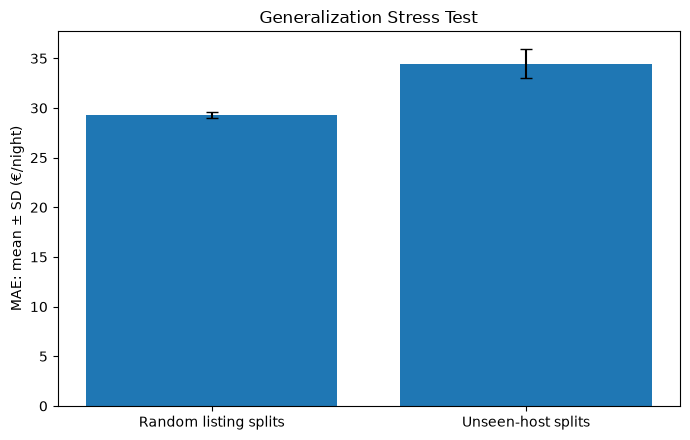

Across the five zero-overlap host splits, mean MAE was **€34.45**, which is **€5.13** higher than the selected model's repeated random-split mean. This indicates that predicting listings from previously unseen hosts is harder than predicting new listings from the same overall host population.

In [5]:
host_runs = result_table("host_generalization_runs")
host_summary = result_table("host_generalization_summary")
display(host_runs)
display(host_summary)

selected_random = stability.loc[
    stability["model"].eq(metadata["selected_model"])
].iloc[0]
selected_grouped = host_summary.iloc[0]
mae_increase = selected_grouped["mean_mae"] - selected_random["mean_mae"]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(
    ["Random listing splits", "Unseen-host splits"],
    [selected_random["mean_mae"], selected_grouped["mean_mae"]],
    yerr=[selected_random["sd_mae"], selected_grouped["sd_mae"]],
    capsize=4,
)
ax.set_ylabel("MAE: mean ± SD (€/night)")
ax.set_title("Generalization Stress Test")
fig.tight_layout()
plt.show()

display(Markdown(
    f"Across the five zero-overlap host splits, mean MAE was "
    f"**€{selected_grouped['mean_mae']:.2f}**, which is "
    f"**€{mae_increase:.2f}** higher than the selected model's repeated "
    "random-split mean. This indicates that predicting listings from previously "
    "unseen hosts is harder than predicting new listings from the same overall host population."
))


## 5. Error penalty and Gradient Boosting loss

,loss,mean_mae,sd_mae,mean_rmse,sd_rmse,mean_r2,mean_within_25,mean_within_50
0,huber,31.758,0.603,50.143,1.287,0.620,0.574,0.826
1,squared_error,32.170,0.676,48.844,1.047,0.640,0.551,0.816
2,absolute_error,32.242,0.558,52.234,1.370,0.588,0.586,0.820


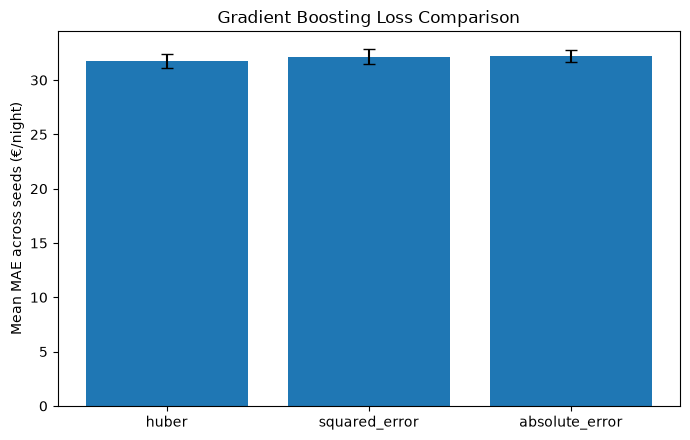

**huber** produced the lowest repeated-split MAE, while **squared_error** produced the lowest RMSE. This reinforces that the preferred training loss depends on how strongly large errors should be weighted.

In [6]:
loss_comparison = result_table("loss_comparison").sort_values("mean_mae").reset_index(drop=True)
display(loss_comparison)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(loss_comparison["loss"], loss_comparison["mean_mae"], yerr=loss_comparison["sd_mae"], capsize=4)
ax.set_ylabel("Mean MAE across seeds (€/night)")
ax.set_title("Gradient Boosting Loss Comparison")
fig.tight_layout()
plt.show()

best_mae_loss = loss_comparison.iloc[0]
best_rmse_loss = loss_comparison.sort_values("mean_rmse").iloc[0]
display(Markdown(
    f"**{best_mae_loss['loss']}** produced the lowest repeated-split MAE, while "
    f"**{best_rmse_loss['loss']}** produced the lowest RMSE. This reinforces that the preferred "
    "training loss depends on how strongly large errors should be weighted."
))

## 6. Spatial and text ablations

Three modalities were evaluated across the project. The final Random Forest retains tabular and spatial information because full spatial features improve prediction, whereas the six text length/count summaries do not improve its validation MAE. This conclusion applies only to these simple text-derived quantities, not to semantic text representations.

,model,spatial_setting,mean_mae,sd_mae,mean_rmse,mean_r2,mean_within_25,mean_within_50
1,Random Forest — log target,full_spatial,29.316,0.288,48.593,0.643,0.628,0.842
0,Random Forest — log target,coarse_location,30.837,0.689,50.111,0.621,0.610,0.828
2,Random Forest — log target,no_spatial,31.368,0.642,50.610,0.613,0.600,0.825
4,Ridge Regression,full_spatial,38.193,0.585,55.145,0.541,0.447,0.750
3,Ridge Regression,coarse_location,38.732,0.593,55.870,0.529,0.443,0.743
5,Ridge Regression,no_spatial,39.459,0.543,56.930,0.510,0.444,0.739


,model,text_setting,mean_mae,sd_mae,mean_rmse,mean_r2
1,Random Forest — log target,without_text,29.316,0.288,48.593,0.643
0,Random Forest — log target,with_text,29.366,0.367,48.764,0.641
2,Ridge Regression,with_text,38.193,0.585,55.145,0.541
3,Ridge Regression,without_text,38.409,0.638,55.413,0.536


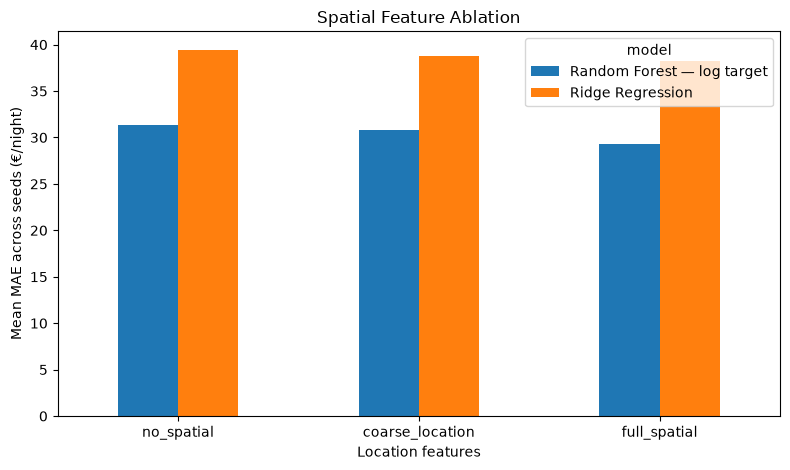

For the log-target Random Forest, full spatial information reduced repeated-split MAE by **€2.05** relative to removing all spatial variables. The six text-length and word-count variables did not provide a meaningful Random Forest gain; this does not test semantic text representations such as TF-IDF or embeddings.

In [7]:
spatial = result_table("spatial_ablation")
text_ablation = result_table("text_ablation")
display(spatial.sort_values(["model", "mean_mae"]))
display(text_ablation.sort_values(["model", "mean_mae"]))

fig, ax = plt.subplots(figsize=(8, 4.8))
pivot = spatial.pivot(index="spatial_setting", columns="model", values="mean_mae")
pivot.loc[["no_spatial", "coarse_location", "full_spatial"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Mean MAE across seeds (€/night)")
ax.set_xlabel("Location features")
ax.set_title("Spatial Feature Ablation")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

rf_spatial = spatial.loc[spatial["model"].str.startswith("Random Forest")]
no_spatial_mae = rf_spatial.loc[rf_spatial["spatial_setting"].eq("no_spatial"), "mean_mae"].iloc[0]
full_spatial_mae = rf_spatial.loc[rf_spatial["spatial_setting"].eq("full_spatial"), "mean_mae"].iloc[0]
display(Markdown(
    f"For the log-target Random Forest, full spatial information reduced repeated-split MAE by "
    f"**€{no_spatial_mae - full_spatial_mae:.2f}** relative to removing all spatial variables. "
    "The six text-length and word-count variables did not provide a meaningful Random Forest gain; "
    "this does not test semantic text representations such as TF-IDF or embeddings."
))

## 7. Error analysis for the selected model

In [8]:
price_band_errors = result_table("price_band_errors")
room_type_errors = result_table("room_type_errors")
display(price_band_errors)
display(room_type_errors)

worst_band = price_band_errors.sort_values("mae", ascending=False).iloc[0]
small_groups = room_type_errors.loc[room_type_errors["n"] < 30, "room_type"].tolist()
display(Markdown(
    f"The largest error occurs in **{worst_band['price_quartile']}**, with MAE "
    f"**€{worst_band['mae']:.2f}**. The upper tail remains the main failure mode. "
    f"Subgroup estimates for {', '.join(small_groups)} are based on fewer than 30 test listings "
    "and should not be generalized confidently."
))

,price_quartile,n,mae,median_ae,within_25,within_50
0,Q1: lowest,481,14.527,11.026,0.811,0.973
1,Q2,437,17.979,13.884,0.771,0.959
2,Q3,459,23.695,18.903,0.627,0.908
3,Q4: highest,458,62.381,45.991,0.314,0.533


,room_type,n,mae,median_ae,within_25,within_50
0,Entire home/apt,1320,33.754,21.340,0.570,0.814
1,Hotel room,18,47.449,20.525,0.556,0.611
2,Private room,478,18.265,11.146,0.791,0.929
3,Shared room,19,7.883,5.723,0.947,1.000


The largest error occurs in **Q4: highest**, with MAE **€62.38**. The upper tail remains the main failure mode. Subgroup estimates for Hotel room, Shared room are based on fewer than 30 test listings and should not be generalized confidently.

### Calibration and unequal error spread

The residual summaries group held-out listings by predicted-price decile. Positive mean residuals indicate underprediction. Increasing residual standard deviation and MAE show that absolute euro errors are not equally variable across the price range.

This pattern does not invalidate Random Forest regression, which does not require homoscedastic residuals for coefficient inference. It does mean that expensive predictions are less precise and should be interpreted more cautiously.

,prediction_decile,n,mean_actual_price,mean_predicted_price,mean_signed_residual,residual_sd,mae
0,1,184,47.076,48.054,-0.978,14.120,10.128
1,2,183,61.995,63.262,-1.268,17.870,12.823
2,3,184,78.043,72.632,5.412,28.287,19.121
3,4,183,92.208,85.123,7.085,32.702,21.669
4,5,184,98.332,98.530,-0.198,33.082,22.459
5,6,183,121.137,112.783,8.353,57.681,31.469
6,7,183,140.945,128.940,12.005,52.659,33.938
7,8,184,162.158,147.792,14.366,51.929,36.907
8,9,183,187.268,177.105,10.162,65.802,46.399
9,10,184,274.620,248.085,26.535,80.350,60.938


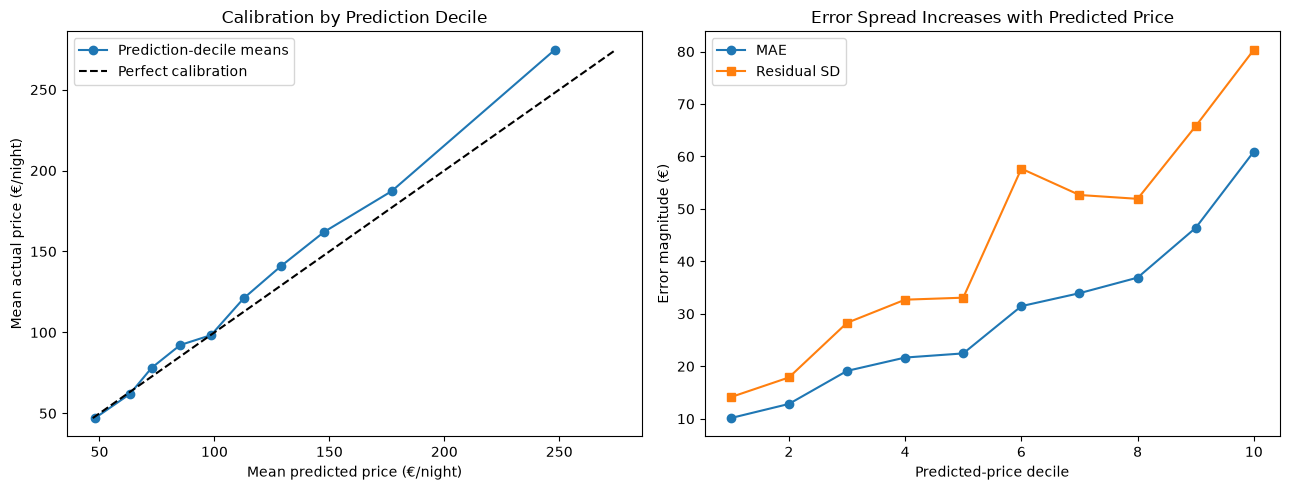

In [9]:
residual_bins = result_table("residual_bin_summary")
calibration = result_table("calibration_by_decile")
display(residual_bins)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    calibration["mean_predicted_price"],
    calibration["mean_actual_price"],
    marker="o",
    label="Prediction-decile means",
)
calibration_limits = [
    min(calibration["mean_predicted_price"].min(), calibration["mean_actual_price"].min()),
    max(calibration["mean_predicted_price"].max(), calibration["mean_actual_price"].max()),
]
axes[0].plot(
    calibration_limits,
    calibration_limits,
    linestyle="--",
    color="black",
    label="Perfect calibration",
)
axes[0].set_xlabel("Mean predicted price (€/night)")
axes[0].set_ylabel("Mean actual price (€/night)")
axes[0].set_title("Calibration by Prediction Decile")
axes[0].legend()

axes[1].plot(
    residual_bins["prediction_decile"],
    residual_bins["mae"],
    marker="o",
    label="MAE",
)
axes[1].plot(
    residual_bins["prediction_decile"],
    residual_bins["residual_sd"],
    marker="s",
    label="Residual SD",
)
axes[1].set_xlabel("Predicted-price decile")
axes[1].set_ylabel("Error magnitude (€)")
axes[1].set_title("Error Spread Increases with Predicted Price")
axes[1].legend()

fig.tight_layout()
plt.show()

## 8. Feature importance and uncertainty

,feature,importance_mean,importance_sd
0,minimum_nights,12.656,0.665
1,accommodates,10.235,0.403
2,room_type_Private room,6.205,0.374
3,bedrooms,6.036,0.439
4,distance_to_center_km,3.588,0.302
5,bathrooms_parsed,2.807,0.207
6,host_listings_count,2.052,0.098
7,instant_bookable,1.265,0.107
8,room_type_Shared room,1.244,0.100
9,host_total_listings_count,0.954,0.060


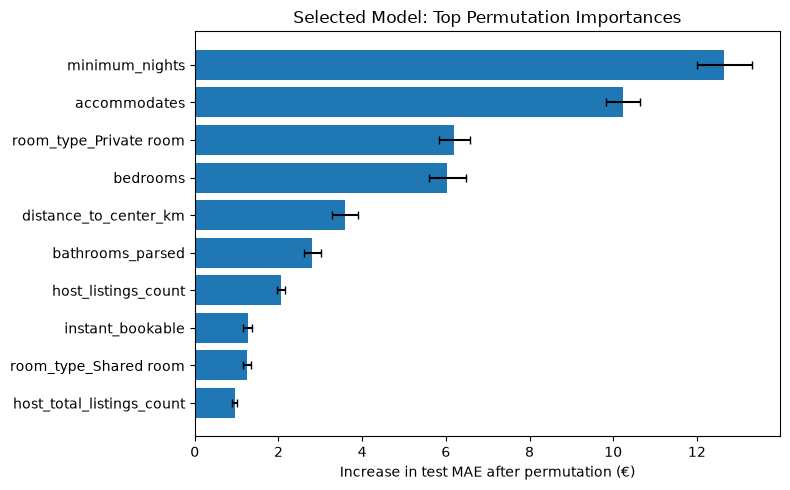

,metric,bootstrap_unit,estimate,ci_2.5%,ci_97.5%
0,MAE,listing,29.586,27.886,31.430
1,MAE,host cluster,29.586,27.669,31.646
2,RMSE,listing,49.244,45.081,53.668
3,RMSE,host cluster,49.244,44.867,53.817


Permutation importance measures predictive contribution, not causal effect. Correlated features can divide or mask importance. The listing bootstrap treats test listings as independent, while the host-cluster bootstrap resamples complete hosts and allows within-host dependence. Neither interval includes future market shift or uncertainty from repeating the complete model-selection process.

In [10]:
feature_importance = result_table("feature_importance")
bootstrap_intervals = result_table("bootstrap_intervals")
display(feature_importance)

fig, ax = plt.subplots(figsize=(8, 5))
plot_data = feature_importance.head(10).sort_values("importance_mean")
ax.barh(
    plot_data["feature"],
    plot_data["importance_mean"],
    xerr=plot_data["importance_sd"],
    capsize=3,
)
ax.set_xlabel("Increase in test MAE after permutation (€)")
ax.set_title("Selected Model: Top Permutation Importances")
fig.tight_layout()
plt.show()

display(bootstrap_intervals)

display(Markdown(
    "Permutation importance measures predictive contribution, not causal effect. "
    "Correlated features can divide or mask importance. The listing bootstrap treats "
    "test listings as independent, while the host-cluster bootstrap resamples complete "
    "hosts and allows within-host dependence. Neither interval includes future market "
    "shift or uncertainty from repeating the complete model-selection process."
))


## 9. Final conclusions and limitations

In [11]:
selected_host_mae = host_summary.loc[0, "mean_mae"]
selected_row = model_comparison.loc[
    model_comparison["model"].eq(metadata["selected_model"])
].iloc[0]
raw_rf_row = model_comparison.loc[
    model_comparison["model"].eq("Random Forest — raw target, full features")
].iloc[0]
highest_price_mae = price_band_errors.loc[
    price_band_errors["price_quartile"].eq("Q4: highest"), "mae"
].iloc[0]

display(Markdown(f"""
1. All trained models outperform the constant baselines, and nonlinear models outperform the linear references.
2. **{metadata['selected_model']}** provides the lowest training-selected MAE among the tested candidates.
3. Three modalities were evaluated. The selected model retains tabular and spatial predictors because the six simple text-quantity features did not improve Random Forest validation performance.
4. The PyTorch MLP is competitive but does not improve the primary metric enough to replace the selected Random Forest.
5. Full spatial information provides a meaningful predictive gain.
6. The log-target Random Forest is preferred for MAE (**€{selected_row['test_mae']:.2f}**), while the raw-target Random Forest has better RMSE (**€{raw_rf_row['test_rmse']:.2f}**) and R² (**{raw_rf_row['test_r2']:.3f}**). The selected model is therefore not universally best on every metric.
7. The selected model performs most reliably for typical listings. Absolute errors increase with price, and the highest actual-price quartile has MAE **€{highest_price_mae:.2f}**; expensive-listing predictions should be treated cautiously.
8. The unseen-host stress test is harder, with mean MAE **€{selected_host_mae:.2f}** across five zero-overlap host splits.

### Important limitations

- The 99th-percentile price restriction and one-hot category vocabulary were defined during Parts 1 and 2 before splitting. Numeric fill values from those notebooks are not used for model fitting: Notebook 3 reconstructs the relevant missing entries and fits median imputation inside each training split or fold.
- The model's declared target population excludes listings with missing prices and the removed extreme upper tail.
- The compact searches reuse the same training cross-validation folds; selection scores can therefore be mildly optimistic. The fixed test set provides the main independent evaluation.
- The grouped host analysis is a secondary stress test of the already selected configuration, not a separate independent model-selection benchmark.
- Original-scale residuals have unequal variance. Random Forest fitting does not require homoscedastic errors for coefficient inference, but this pattern means uncertainty grows for expensive listings.
- A single Berlin snapshot cannot establish performance for future market conditions, other cities, or changing platform behavior.
- The text modality measures text quantity rather than semantic content.
- The analysis is predictive and does not support causal claims.
"""))


1. All trained models outperform the constant baselines, and nonlinear models outperform the linear references.
2. **Random Forest — log target, no text** provides the lowest training-selected MAE among the tested candidates.
3. Three modalities were evaluated. The selected model retains tabular and spatial predictors because the six simple text-quantity features did not improve Random Forest validation performance.
4. The PyTorch MLP is competitive but does not improve the primary metric enough to replace the selected Random Forest.
5. Full spatial information provides a meaningful predictive gain.
6. The log-target Random Forest is preferred for MAE (**€29.59**), while the raw-target Random Forest has better RMSE (**€48.32**) and R² (**0.658**). The selected model is therefore not universally best on every metric.
7. The selected model performs most reliably for typical listings. Absolute errors increase with price, and the highest actual-price quartile has MAE **€62.38**; expensive-listing predictions should be treated cautiously.
8. The unseen-host stress test is harder, with mean MAE **€34.45** across five zero-overlap host splits.

### Important limitations

- The 99th-percentile price restriction and one-hot category vocabulary were defined during Parts 1 and 2 before splitting. Numeric fill values from those notebooks are not used for model fitting: Notebook 3 reconstructs the relevant missing entries and fits median imputation inside each training split or fold.
- The model's declared target population excludes listings with missing prices and the removed extreme upper tail.
- The compact searches reuse the same training cross-validation folds; selection scores can therefore be mildly optimistic. The fixed test set provides the main independent evaluation.
- The grouped host analysis is a secondary stress test of the already selected configuration, not a separate independent model-selection benchmark.
- Original-scale residuals have unequal variance. Random Forest fitting does not require homoscedastic errors for coefficient inference, but this pattern means uncertainty grows for expensive listings.
- A single Berlin snapshot cannot establish performance for future market conditions, other cities, or changing platform behavior.
- The text modality measures text quantity rather than semantic content.
- The analysis is predictive and does not support causal claims.
